In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("data/bank_customer_data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1500, 15)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,LOAN_HOLDINGS,TENURE
0,C10001,6245.071230,0.985,4520.46,2843.38,1677.08,476.62,0.875,47,9797.33,3475.43,1410.61,0.347,2,12
1,C10002,5292.603548,0.921,5267.56,3872.24,1395.32,284.43,0.993,59,10219.45,5352.20,1009.04,0.308,0,12
2,C10003,6471.532807,0.950,4298.74,3554.41,744.33,263.90,0.818,38,14966.84,4424.07,NaN,0.737,2,12
3,C10004,7784.544785,0.876,5478.58,3858.41,1620.17,938.62,0.937,49,15590.84,4039.45,1233.67,0.418,2,12
4,C10005,5148.769938,0.879,3579.25,2861.52,717.74,359.75,0.899,43,11404.72,2564.09,1205.13,0.406,0,12


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Columns:
['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'LOAN_HOLDINGS', 'TENURE']

Data types:
CUST_ID                       str
BALANCE                   float64
BALANCE_FREQUENCY         float64
PURCHASES                 float64
ONEOFF_PURCHASES          float64
INSTALLMENTS_PURCHASES    float64
CASH_ADVANCE              float64
PURCHASES_FREQUENCY       float64
PURCHASES_TRX               int64
CREDIT_LIMIT              float64
PAYMENTS                  float64
MINIMUM_PAYMENTS          float64
PRC_FULL_PAYMENT          float64
LOAN_HOLDINGS               int64
TENURE                      int64
dtype: object

Missing values:
CUST_ID                    0
BALANCE                   45
BALANCE_FREQUENCY          0
PURCHASES                  0
ONEOFF_PURCHASES           0
INSTALLMENTS_PURCHASES     0
CASH_ADVA

In [4]:
df_clean = df.copy()

numeric_cols = df_clean.select_dtypes(include=np.number).columns

for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
CUST_ID                   0
BALANCE                   0
BALANCE_FREQUENCY         0
PURCHASES                 0
ONEOFF_PURCHASES          0
INSTALLMENTS_PURCHASES    0
CASH_ADVANCE              0
PURCHASES_FREQUENCY       0
PURCHASES_TRX             0
CREDIT_LIMIT              0
PAYMENTS                  0
MINIMUM_PAYMENTS          0
PRC_FULL_PAYMENT          0
LOAN_HOLDINGS             0
TENURE                    0
dtype: int64


In [5]:
feature_cols = [
    col for col in numeric_cols
    if col != "CUST_ID"
]

X = df_clean[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Number of features:", len(feature_cols))
print("Scaled data shape:", X_scaled.shape)

Number of features: 14
Scaled data shape: (1500, 14)


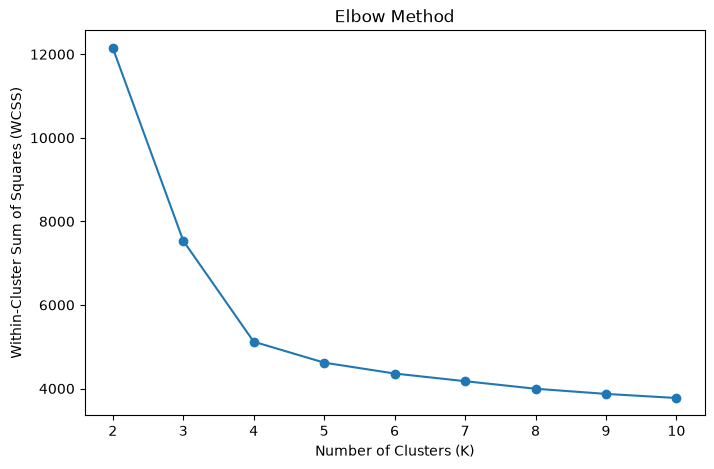

In [6]:
inertias = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method")
plt.show()

In [7]:
k = 4

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df_clean["Cluster"] = clusters

print("Cluster counts:")
print(df_clean["Cluster"].value_counts().sort_index())

Cluster counts:
Cluster
0    525
1    225
2    450
3    300
Name: count, dtype: int64


In [8]:
hierarchical = AgglomerativeClustering(n_clusters=4)

hierarchical_clusters = hierarchical.fit_predict(X_scaled)

df_clean["Hierarchical_Cluster"] = hierarchical_clusters

print("Hierarchical clustering completed.")
print(df_clean["Hierarchical_Cluster"].value_counts().sort_index())

Hierarchical clustering completed.
Hierarchical_Cluster
0    525
1    450
2    300
3    225
Name: count, dtype: int64


In [9]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total variance explained:",
      pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.52394791 0.21617285]
Total variance explained: 0.7401207521008821


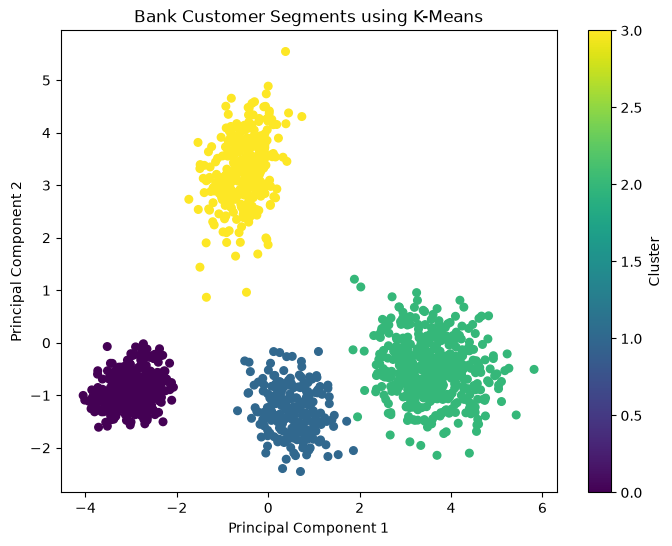

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="viridis",
    s=30
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Bank Customer Segments using K-Means")
plt.colorbar(label="Cluster")

plt.show()

In [11]:
print("Cluster Profiles:\n")

cluster_profile = df_clean.groupby("Cluster")[feature_cols].mean()

try:
    display(cluster_profile)
except NameError:
    print(cluster_profile)

print("\nCluster Sizes:")
print(df_clean["Cluster"].value_counts().sort_index())

# Save cleaned data with cluster labels
df_clean.to_csv(
    "data/bank_customer_data_clustered.csv",
    index=False
)

print("\nClustered dataset saved successfully.")


Cluster Profiles:



,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,LOAN_HOLDINGS,TENURE
Cluster,,,,,,,,,,,,,,
0,829.544495,0.592716,250.887905,126.134514,124.753352,110.482419,0.255950,4.958095,3051.853771,496.743029,261.427343,0.154244,0.207619,9.053333
1,1556.475208,0.853204,2217.716622,269.505644,1948.210756,158.387600,0.849471,27.897778,5495.199333,1800.506356,524.788978,0.401973,0.720000,10.480000
2,5451.591613,0.921724,4342.335267,3252.913956,1089.421711,314.106133,0.900073,45.446667,12082.786656,3922.779556,1138.549911,0.545109,0.651111,11.595556
3,4458.344217,0.897937,517.205400,183.964000,333.241200,4894.034933,0.306973,8.156667,7581.825950,3153.821100,1798.447450,0.075470,1.800000,10.043333



Cluster Sizes:
Cluster
0    525
1    225
2    450
3    300
Name: count, dtype: int64

Clustered dataset saved successfully.
